# 作业4-5：CNN、RNN、Transformer 及 AI 辅助编程练习

## 1. 卷积神经网络

### 1.1 目标

通过对 MNIST 数据进行训练，构建一个简单的图像分类模型，对图片中的数字进行识别。你将利用该模型对自己真实手写出的数字进行预测，观察模型效果。

### 1.2 主要步骤

1. 获取数据
2. 定义模型结构
3. 创建模型类
4. 定义损失函数
5. 编写训练循环
6. 实施预测

### 1.3 获取数据

我们使用知名的 MNIST 数据集，它可以从 PyTorch 中利用工具函数下载得到。MNIST 数据训练集大小为60000，我们将**使用完整训练集进行训练**，并对10个测试集观测进行预测展示。以下函数会在当前目录建立一个名为 data 的文件夹，其中会包含下载得到的数据集。

**注意：请在任何程序的最开始加上随机数种子的设置。请保持这一习惯。**

In [11]:
import numpy as np
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

np.random.seed(123456)
torch.manual_seed(123456)

mnist = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist, batch_size=60000, shuffle=True)

我们一次性取出60000个观测，其中 x 是图片数据，y 是图片对应的数字。

In [8]:
x, y = next(iter(loader))

一个习惯性动作是查看数据的大小和维度。

In [9]:
print(x.shape)
print(y.shape)

torch.Size([60000, 1, 28, 28])
torch.Size([60000])


用类似的方法获取测试集，并取出10个观测：

In [10]:
mnist_test = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist_test, batch_size=10, shuffle=True)

xtest, ytest = next(iter(loader))
print(xtest.shape)
print(ytest.shape)

torch.Size([10, 1, 28, 28])
torch.Size([10])


我们可以利用下面的函数展示图片的内容。如选择第一张测试图片，先将其转换成 Numpy 数组，再绘制图形：

(28, 28)


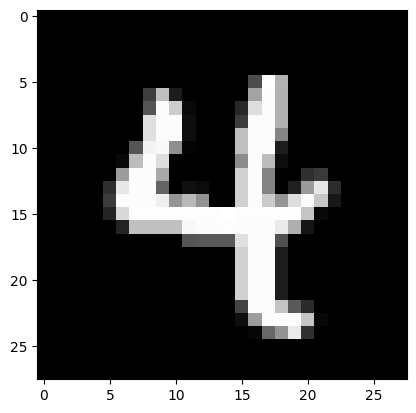

In [12]:
import matplotlib.pyplot as plt

img = xtest[0].squeeze().cpu().numpy()
print(img.shape)
plt.imshow(img, cmap="gray")
plt.show()

接下来请你选择5个你喜欢的数字（60000以下），然后取出训练集中对应位置的图片，并画出它们的内容。

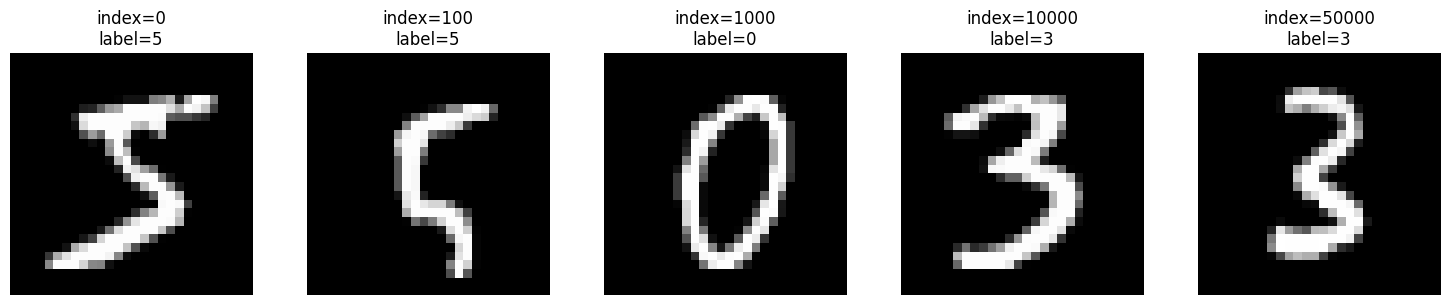

In [20]:
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# 加载MNIST训练集
mnist_train = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

# 选择5个小于60000的位置
selected_indices = [0, 100, 1000, 10000, 50000]

# 创建画布
plt.figure(figsize=(15, 3))

for i, index in enumerate(selected_indices):
    # 从训练集中取出图像和标签
    image, label = mnist_train[index]

    # 将[1, 28, 28]变为[28, 28]
    image = image.squeeze().numpy()

    # 绘制图像
    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"index={index}\nlabel={label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 1.4 定义模型结构

我们搭建一个类似于 LeNet-5 的网络，结构如下：

![](https://pic1.zhimg.com/80/v2-82eabb4c17e90d467197d013f7629f3c_720w.jpg)

我们需要创建2个卷积层、2个汇聚层和2个全连接层，**暂时忽略所有的激活函数**。所有隐藏层的函数细节都可以在[官方文档](https://pytorch.org/docs/stable/nn.html)中按分类找到。每一个隐藏层本质上都是将一个数组变换成另一个数组的函数，因此为了确认编写的模型是正确的，可以先用一个小数据进行测试，观察输入和输出的维度。例如，我们先取出前6个观测，此时输入的维度是 `[6, 1, 28, 28]`：

In [14]:
ns = 6
smallx = x[0:ns]
smally = y[0:ns]
print(smallx.shape)
print(smally.shape)

torch.Size([6, 1, 28, 28])
torch.Size([6])


接下来创建第1个卷积层，并测试输出的维度。注意到我们可以直接将隐藏层当成一个函数来调用。

In [15]:
conv1 = torch.nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)
res1 = conv1(smallx)
print(res1.shape)

torch.Size([6, 20, 24, 24])


可以看到，输出的维度为 `[20, 24, 24]`（不包括第1位的数据批次维度），与之前图中的结果吻合。

接下来，请按照图中提示编写层对象 `pool1`、`conv2`、`pool2`、`fc1` 和 `fc2`，并顺次测试输入与输出的维度，使其与上图匹配。注意，在将一个大小为 `[6, 50, 4, 4]` 的数组（假设叫 `somearray`）传递给 `fc1` 之前，需要先将其变形为只有两个维度的数组，做法是 `somearray.view(-1, 50 * 4 * 4)`，其中 -1 表示该位置的大小不变。也可以使用 `torch.flatten()` 函数并指定其中的 `start_dim` 参数（请搜索其对应的函数文档）。

```py
pool1 = ...
res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

conv2 = ...
res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

pool2 = ...
res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

fc1 = ...
res5 = fc1(res4.view(-1, 800))
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

fc2 = ...
res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"
```

In [21]:
import torch
import torch.nn as nn

# 当前批次中的样本数量
ns = res1.shape[0]

# 第1个池化层：将24×24缩小为12×12
pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

# 第2个卷积层：20个输入通道，50个输出通道
# 12 - 5 + 1 = 8
conv2 = nn.Conv2d(
    in_channels=20,
    out_channels=50,
    kernel_size=5,
    stride=1
)

res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

# 第2个池化层：将8×8缩小为4×4
pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

# 第1个全连接层
# 每个样本共有50×4×4=800个特征
fc1 = nn.Linear(
    in_features=50 * 4 * 4,
    out_features=500
)

# 将[ns, 50, 4, 4]展平为[ns, 800]
res4_flat = res4.view(res4.shape[0], -1)

res5 = fc1(res4_flat)
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

# 第2个全连接层：输出10个类别
fc2 = nn.Linear(
    in_features=500,
    out_features=10
)

res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"

torch.Size([6, 20, 12, 12])
torch.Size([6, 50, 8, 8])
torch.Size([6, 50, 4, 4])
torch.Size([6, 500])
torch.Size([6, 10])


### 1.5 创建模型类

在确保隐藏层维度都正确后，将所有的隐藏层封装到一个模型类中，其中模型结构在 `__init__()` 中定义，具体的计算过程在 `forward()` 中实现。此时需要加入激活函数。在本模型中，**请在 `conv1`、`conv2` 和 `fc1` 后加入 ReLU 激活函数，并在 `fc2` 后加入 Softmax 激活函数**。

```py
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ...
        self.pool1 = ...
        self.conv2 = ...
        self.pool2 = ...
        self.fc1 = ...
        self.fc2 = ...

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        ...
        return x
```

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        # 第1个卷积层：
        # [N, 1, 28, 28] -> [N, 20, 24, 24]
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=20,
            kernel_size=5,
            stride=1
        )

        # 第1个池化层：
        # [N, 20, 24, 24] -> [N, 20, 12, 12]
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # 第2个卷积层：
        # [N, 20, 12, 12] -> [N, 50, 8, 8]
        self.conv2 = nn.Conv2d(
            in_channels=20,
            out_channels=50,
            kernel_size=5,
            stride=1
        )

        # 第2个池化层：
        # [N, 50, 8, 8] -> [N, 50, 4, 4]
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # 第1个全连接层：
        # 50 × 4 × 4 = 800
        self.fc1 = nn.Linear(
            in_features=50 * 4 * 4,
            out_features=500
        )

        # 第2个全连接层：
        # 输出10个数字类别
        self.fc2 = nn.Linear(
            in_features=500,
            out_features=10
        )

    def forward(self, x):
        # 第1个卷积层后使用ReLU
        x = self.conv1(x)
        x = torch.relu(x)

        # 第1个池化层
        x = self.pool1(x)

        # 第2个卷积层后使用ReLU
        x = self.conv2(x)
        x = torch.relu(x)

        # 第2个池化层
        x = self.pool2(x)

        # 将[N, 50, 4, 4]展平为[N, 800]
        x = torch.flatten(x, start_dim=1)

        # 第1个全连接层后使用ReLU
        x = self.fc1(x)
        x = torch.relu(x)

        # 第2个全连接层
        x = self.fc2(x)

        # 将10个输出转换为概率
        x = torch.softmax(x, dim=1)

        return x

再次测试输入输出的维度是否正确。如果模型编写正确，输出的维度应该是 `[6, 10]`，且输出结果为0到1之间的概率值。

In [23]:
np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
pred = model(smallx)
print(pred.shape)
print()
print(pred)
print()
print(torch.sum(pred, dim=1))

torch.Size([6, 10])

tensor([[0.0975, 0.1003, 0.0987, 0.1080, 0.0927, 0.0913, 0.0983, 0.1060, 0.1013,
         0.1058],
        [0.0971, 0.1000, 0.1006, 0.1078, 0.0939, 0.0914, 0.1014, 0.1017, 0.1025,
         0.1037],
        [0.0958, 0.0996, 0.0984, 0.1092, 0.0932, 0.0923, 0.0984, 0.1066, 0.1022,
         0.1043],
        [0.0991, 0.1006, 0.0990, 0.1091, 0.0918, 0.0889, 0.0989, 0.1061, 0.1042,
         0.1021],
        [0.0954, 0.1004, 0.1015, 0.1071, 0.0943, 0.0922, 0.1017, 0.1023, 0.1027,
         0.1024],
        [0.0962, 0.1011, 0.0987, 0.1094, 0.0923, 0.0906, 0.0958, 0.1088, 0.1024,
         0.1048]], grad_fn=<SoftmaxBackward0>)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


`pred` 的每一行加总为1，其中每一个元素代表对应类别的预测概率。

我们还可以直接打印模型对象，观察隐藏层的结构：

In [24]:
print(model)

MyModel(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)


### 1.6 定义损失函数

对于分类问题，损失函数通常选取为负对数似然函数。在 PyTorch 中，可以使用 `torch.nn.NLLLoss` 来完成计算。其用法是先定义一个损失函数对象，然后在预测值和真实标签上调用该函数对象。注意：损失函数对象的第一个参数是预测概率的**对数值**，第二个参数是真实的标签。[文档说明](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)。

In [25]:
lossfn = torch.nn.NLLLoss()
lossfn(torch.log(pred), smally)

tensor(2.3102, grad_fn=<NllLossBackward0>)

### 1.7 编写训练循环

对于本数据，选取 mini-batch 大小为200，共遍历数据3遍，优化器选为 SGD，学习率为0.001。记录每个 mini-batch 下的损失函数值存放到列表 `losses_sgd` 中，然后画出损失函数的曲线。

In [41]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_sgd = []

from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# 构造训练数据加载器
train_loader = DataLoader(
    mnist_train,
    batch_size=batch_size,
    shuffle=True
)

# 定义损失函数
criterion = nn.CrossEntropyLoss()

# 定义SGD优化器
optimizer = optim.SGD(
    model.parameters(),
    lr=lr
)

# 开始训练
for epoch in range(nepoch):

    for batch_x, batch_y in train_loader:

        # 1. 清空上一轮保存的梯度
        optimizer.zero_grad()

        # 2. 前向传播
        pred = model(batch_x)

        # 3. 计算损失
        loss = criterion(pred, batch_y)

        # 4. 反向传播，计算梯度
        loss.backward()

        # 5. 根据梯度更新模型参数
        optimizer.step()

        # 6. 保存当前mini-batch的损失值
        losses_sgd.append(loss.item())

    print(
        f"Epoch [{epoch + 1}/{nepoch}], "
        f"Loss: {loss.item():.4f}"
    )

Epoch [1/3], Loss: 2.3023
Epoch [2/3], Loss: 2.3024
Epoch [3/3], Loss: 2.3026


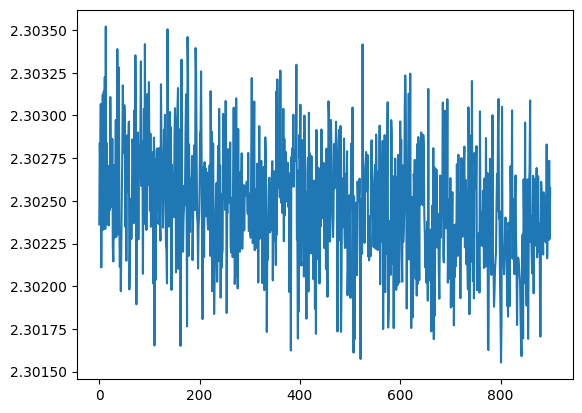

In [42]:
plt.plot(losses_sgd)

接下来使用 Adagrad 优化器（在[官方文档](https://pytorch.org/docs/stable/optim.html)中找到对应的函数），其他参数保持不变，重新训练一次模型，也保存下来损失函数值。

In [43]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_adagrad = []

from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# 创建训练数据加载器
train_loader = DataLoader(
    mnist_train,
    batch_size=batch_size,
    shuffle=True
)

# 定义损失函数
criterion = nn.CrossEntropyLoss()

# 定义Adagrad优化器
optimizer = optim.Adagrad(
    model.parameters(),
    lr=lr
)

# 训练模型
for epoch in range(nepoch):
    for batch_x, batch_y in train_loader:

        # 清空上一轮梯度
        optimizer.zero_grad()

        # 前向传播
        pred = model(batch_x)

        # 计算损失
        loss = criterion(pred, batch_y)

        # 反向传播
        loss.backward()

        # 更新模型参数
        optimizer.step()

        # 保存当前mini-batch的损失值
        losses_adagrad.append(loss.item())

    print(
        f"Epoch [{epoch + 1}/{nepoch}], "
        f"Loss: {loss.item():.4f}"
    )

Epoch [1/3], Loss: 1.5603
Epoch [2/3], Loss: 1.5412
Epoch [3/3], Loss: 1.4969


对比 SGD 和 Adagrad，画出各自的损失函数曲线。

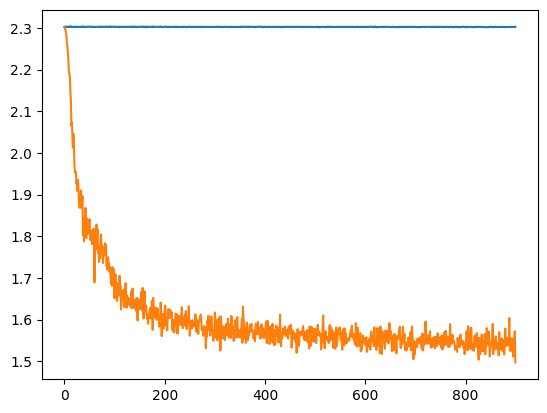

In [44]:
plt.plot(losses_sgd)
plt.plot(losses_adagrad)

最后再自行选择一款优化器，重复上面的实验，并画出三种优化器的损失函数值对比图。

Epoch [1/3], Loss: 1.4824
Epoch [2/3], Loss: 1.4769
Epoch [3/3], Loss: 1.4711


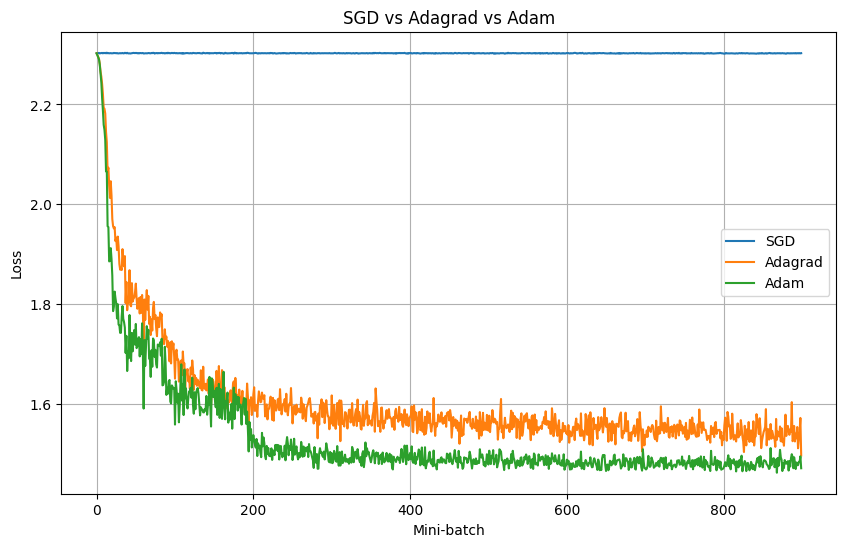

In [46]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

# 重新创建模型，确保Adam从初始状态开始训练
model = MyModel()

losses_adam = []

train_loader = DataLoader(
    mnist_train,
    batch_size=batch_size,
    shuffle=True
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr
)

for epoch in range(nepoch):

    for batch_x, batch_y in train_loader:

        optimizer.zero_grad()

        pred = model(batch_x)

        loss = criterion(pred, batch_y)

        loss.backward()

        optimizer.step()

        losses_adam.append(loss.item())

    print(
        f"Epoch [{epoch + 1}/{nepoch}], "
        f"Loss: {loss.item():.4f}"
    )

# 绘制三种优化器的损失曲线
plt.figure(figsize=(10, 6))

plt.plot(losses_sgd, label="SGD")
plt.plot(losses_adagrad, label="Adagrad")
plt.plot(losses_adam, label="Adam")

plt.xlabel("Mini-batch")
plt.ylabel("Loss")
plt.title("SGD vs Adagrad vs Adam")
plt.legend()
plt.grid()

plt.show()

### 1.8 实施预测

为了验证模型的效果，我们对10个测试观测（即之前生成的 `testx`）进行预测。

In [31]:
ypred = model(xtest)
print(np.round(ypred.detach().cpu().numpy(), 3))
print(ytest)

[[0.098 0.098 0.101 0.107 0.093 0.091 0.101 0.103 0.103 0.105]
 [0.095 0.101 0.101 0.108 0.095 0.092 0.101 0.102 0.102 0.103]
 [0.1   0.1   0.098 0.11  0.094 0.091 0.097 0.106 0.103 0.102]
 [0.097 0.101 0.099 0.109 0.094 0.092 0.101 0.101 0.102 0.105]
 [0.098 0.099 0.1   0.111 0.092 0.09  0.097 0.105 0.103 0.106]
 [0.099 0.099 0.096 0.108 0.093 0.091 0.097 0.109 0.103 0.105]
 [0.098 0.098 0.1   0.107 0.094 0.091 0.102 0.104 0.102 0.103]
 [0.098 0.1   0.099 0.109 0.094 0.091 0.1   0.101 0.102 0.105]
 [0.1   0.099 0.097 0.109 0.093 0.091 0.098 0.105 0.103 0.105]
 [0.096 0.1   0.099 0.108 0.092 0.091 0.098 0.109 0.102 0.105]]
tensor([4, 1, 2, 7, 6, 0, 3, 7, 4, 6])


如果模型搭建和训练都正常，那么每一行中概率最大的取值所在的位置应该正好对应真实的标签。我们也可以让 PyTorch 自动找到最大值的位置。

In [32]:
torch.argmax(ypred, dim=1)

tensor([3, 3, 3, 3, 3, 7, 3, 3, 3, 7])

最后，我们用模型对一些真实的手写数字图片进行预测。请你利用绘图软件（如 Windows 自带的绘图，或 Photoshop 等）准备10张正方形黑色底色的图片，每张用鼠标绘制一个数字（**请使用较粗的笔划**），从0到9，然后以0.png，1.png等文件名存储下来，放到当前目录一个名为 digits 的文件夹中。以下是几个例子：
![](digits/sample0.png) ![](digits/sample5.png) ![](digits/sample8.png)

接下来利用 Pillow 软件包读取图片：

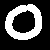

In [33]:
from PIL import Image
im = Image.open("digits/sample0.png")
im

此时如果直接将其转为 Numpy 数组会得到三个或四个通道（可能有一个透明度通道）：

In [34]:
im_arr = np.array(im)
print(im_arr.shape)

(50, 50, 4)


因此，我们先强制转换为灰度图片（单通道），再缩放至模型的图片大小 28 x 28：

In [35]:
im = im.convert("L")
im.thumbnail((28, 28))
im_arr = np.array(im)
print(im_arr.shape)
im

(28, 28)


为了传递给模型对象，还需要先将数值归一化到 [0,1] 区间，转换为 PyTorch 的 Tensor 类型，并增加一个批次和一个通道的维度：

In [36]:
test0 = torch.tensor(im_arr / 255.0, dtype=torch.float32).view(1, 1, 28, 28)
print(test0.shape)

torch.Size([1, 1, 28, 28])


最后对图片标签进行预测：

In [37]:
pred0 = model(test0)
print(np.round(pred0.detach().cpu().numpy(), 3))

[[0.099 0.099 0.099 0.108 0.091 0.092 0.099 0.106 0.101 0.106]]


预测结果是否符合真实情形？请对你自己绘制出的10张图片进行类似的预测操作，并评价其效果。

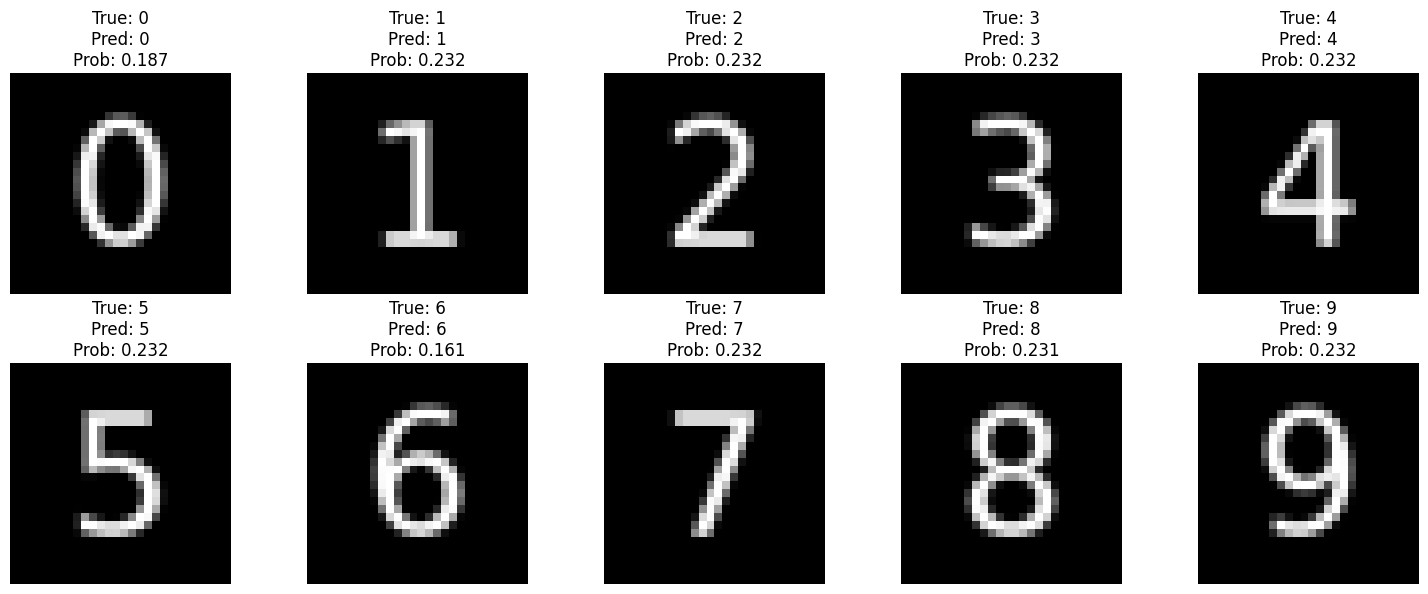

真实标签： [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
预测标签： [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
预测正确数量：10/10
准确率：100.00%


In [48]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# 切换到评估模式
model.eval()

images = []
true_labels = []
pred_labels = []
confidences = []

with torch.no_grad():
    for i in range(10):
        # 读取第i张图片
        image_path = f"{i}.png"
        im = Image.open(image_path)

        # 转为灰度图，并缩放到28×28
        im = im.convert("L")
        im = im.resize((28, 28))

        # 转换为NumPy数组
        im_arr = np.array(im)

        # 如果你的图片是“黑色数字、白色背景”，需要进行颜色反转
        # MNIST通常是“白色数字、黑色背景”
        if im_arr.mean() > 127:
            im_arr = 255 - im_arr

        # 归一化并转换为形状[1, 1, 28, 28]的Tensor
        test_image = torch.tensor(
            im_arr / 255.0,
            dtype=torch.float32
        ).view(1, 1, 28, 28)

        # 模型输出
        output = model(test_image)

        # 如果模型最后没有Softmax，这里转换为概率
        probabilities = torch.softmax(output, dim=1)

        # 获得最高概率及对应类别
        confidence, predicted_label = torch.max(
            probabilities,
            dim=1
        )

        images.append(im_arr)
        true_labels.append(i)
        pred_labels.append(predicted_label.item())
        confidences.append(confidence.item())

# 显示10张图片及预测结果
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")

    plt.title(
        f"True: {true_labels[i]}\n"
        f"Pred: {pred_labels[i]}\n"
        f"Prob: {confidences[i]:.3f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# 计算预测正确率
correct = sum(
    true_labels[i] == pred_labels[i]
    for i in range(10)
)

accuracy = correct / 10

print("真实标签：", true_labels)
print("预测标签：", pred_labels)
print(f"预测正确数量：{correct}/10")
print(f"准确率：{accuracy * 100:.2f}%")

## 2. 循环神经网络

以 `names.txt` 中的英文名作为训练集，利用 RNN 或 LSTM 等方法对字母序列数据进行建模，每个字母视为序列中的一个元素，然后使用拟合的模型随机生成50个名字。本练习为开放式，不指定各类超参数（如网络结构、学习率、迭代次数等），但需提供必要的输出和诊断结果支持你的选择（如模型是否收敛、效果评价等）。

当前设备： cpu
名字数量： 29717
前10个名字： ['aadi', 'aakash', 'aaliyah', 'aamer', 'aamir', 'aan', 'aang', 'aaron', 'aarons', 'aarti']
字符表大小： 29
Epoch [01/30], Loss: 2.4120
Epoch [05/30], Loss: 2.1442
Epoch [10/30], Loss: 2.0591
Epoch [15/30], Loss: 2.0084
Epoch [20/30], Loss: 1.9742
Epoch [25/30], Loss: 1.9548
Epoch [30/30], Loss: 1.9368


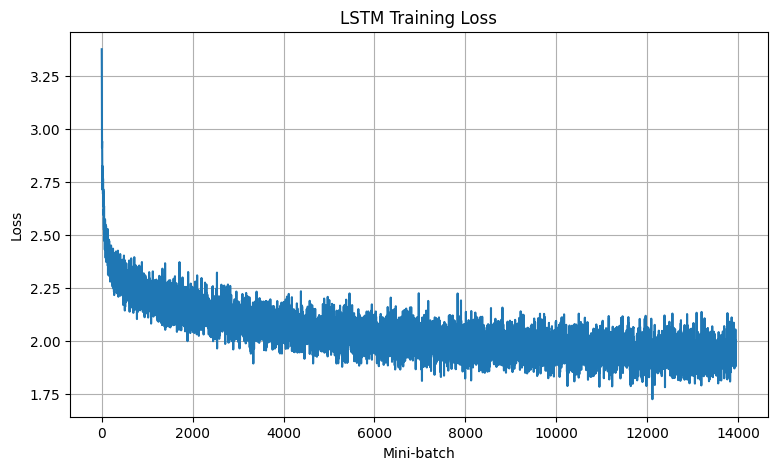


LSTM生成的50个名字：
01. merthel
02. reams
03. peres
04. bakhmarie
05. carrier
06. shab
07. korney
08. mccardleworth
09. mcmean
10. rismet
11. ali
12. hegena
13. triflan
14. kaya
15. caren
16. pepper
17. sanippi
18. salender
19. kien
20. garina
21. pilger
22. dollar
23. kesha
24. lichtenberg
25. tharok
26. greare
27. crouse
28. currin
29. bierman
30. nicalos
31. mehrler
32. riodic
33. ridget
34. olunney
35. menaira
36. sternberg
37. kendeliha
38. rotka
39. bragan
40. lucio
41. fack
42. larsus
43. macken
44. paulie
45. basil
46. brid
47. clarissa
48. phartes
49. mahmadi
50. kuba


In [49]:
import os
import random
import string
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================
# 1. 固定随机种子
# =========================
random.seed(123)
np.random.seed(123)
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前设备：", device)

# =========================
# 2. 读取names.txt
# =========================
file_path = "names.txt"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        "当前目录中没有找到 names.txt，请将 names.txt 放到Notebook所在文件夹中。"
    )

with open(file_path, "r", encoding="utf-8") as f:
    names = [line.strip().lower() for line in f if line.strip()]

# 只保留由英文字母组成的名字
names = [
    "".join(ch for ch in name if ch in string.ascii_lowercase)
    for name in names
]
names = [name for name in names if len(name) > 0]

print("名字数量：", len(names))
print("前10个名字：", names[:10])

# =========================
# 3. 构造字符表
# =========================
PAD_TOKEN = "<PAD>"
BOS_TOKEN = "<BOS>"
EOS_TOKEN = "<EOS>"

chars = list(string.ascii_lowercase)

itos = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN] + chars
stoi = {ch: i for i, ch in enumerate(itos)}

PAD_ID = stoi[PAD_TOKEN]
BOS_ID = stoi[BOS_TOKEN]
EOS_ID = stoi[EOS_TOKEN]

vocab_size = len(itos)

print("字符表大小：", vocab_size)

# =========================
# 4. 创建数据集
# =========================
class NameDataset(Dataset):
    def __init__(self, names):
        self.names = names

    def __len__(self):
        return len(self.names)

    def __getitem__(self, index):
        name = self.names[index]

        # 输入：<BOS> + 名字
        input_ids = [BOS_ID] + [stoi[ch] for ch in name]

        # 标签：名字 + <EOS>
        target_ids = [stoi[ch] for ch in name] + [EOS_ID]

        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(target_ids, dtype=torch.long)
        )


def collate_fn(batch):
    inputs, targets = zip(*batch)

    max_length = max(x.size(0) for x in inputs)
    batch_size = len(inputs)

    padded_inputs = torch.full(
        (batch_size, max_length),
        PAD_ID,
        dtype=torch.long
    )

    padded_targets = torch.full(
        (batch_size, max_length),
        PAD_ID,
        dtype=torch.long
    )

    for i, (input_ids, target_ids) in enumerate(zip(inputs, targets)):
        length = input_ids.size(0)

        padded_inputs[i, :length] = input_ids
        padded_targets[i, :length] = target_ids

    return padded_inputs, padded_targets


dataset = NameDataset(names)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

# =========================
# 5. 定义LSTM模型
# =========================
class LSTMNameModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=64,
        hidden_dim=128,
        num_layers=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_ID
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        output, hidden = self.lstm(x, hidden)
        logits = self.fc(output)

        return logits, hidden


lstm_model = LSTMNameModel(vocab_size).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.003
)

# =========================
# 6. 训练模型
# =========================
num_epochs = 30
losses_lstm = []

for epoch in range(num_epochs):
    lstm_model.train()

    epoch_loss = 0.0

    for input_ids, target_ids in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        optimizer.zero_grad()

        logits, _ = lstm_model(input_ids)

        loss = criterion(
            logits.reshape(-1, vocab_size),
            target_ids.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        epoch_loss += loss.item()
        losses_lstm.append(loss.item())

    average_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}], "
            f"Loss: {average_loss:.4f}"
        )

# =========================
# 7. 绘制损失曲线
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(losses_lstm)
plt.xlabel("Mini-batch")
plt.ylabel("Loss")
plt.title("LSTM Training Loss")
plt.grid()
plt.show()

# =========================
# 8. 生成英文名
# =========================
def generate_lstm_name(
    model,
    max_length=15,
    temperature=0.8
):
    model.eval()

    current_token = torch.tensor(
        [[BOS_ID]],
        dtype=torch.long,
        device=device
    )

    hidden = None
    generated_chars = []

    with torch.no_grad():
        for _ in range(max_length):
            logits, hidden = model(current_token, hidden)

            # 取最后一个时间步
            next_logits = logits[:, -1, :] / temperature

            # 不允许生成PAD或BOS
            next_logits[:, PAD_ID] = float("-inf")
            next_logits[:, BOS_ID] = float("-inf")

            probabilities = torch.softmax(next_logits, dim=-1)

            next_token = torch.multinomial(
                probabilities,
                num_samples=1
            )

            token_id = next_token.item()

            if token_id == EOS_ID:
                break

            generated_chars.append(itos[token_id])

            current_token = next_token

    return "".join(generated_chars)


generated_lstm_names = []

while len(generated_lstm_names) < 50:
    name = generate_lstm_name(
        lstm_model,
        max_length=15,
        temperature=0.8
    )

    if len(name) >= 2:
        generated_lstm_names.append(name)

print("\nLSTM生成的50个名字：")

for i, name in enumerate(generated_lstm_names, 1):
    print(f"{i:02d}. {name}")

## 3. Transformer

利用 Transformer 类型的网络架构，同样对 `names.txt` 中的英文名进行序列建模和训练，再使用拟合的模型随机生成50个名字。

/opt/anaconda3/envs/xigua/lib/python3.12/site-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch [01/30], Loss: 2.4466
Epoch [05/30], Loss: 2.2988
Epoch [10/30], Loss: 2.2530
Epoch [15/30], Loss: 2.2225
Epoch [20/30], Loss: 2.2017
Epoch [25/30], Loss: 2.1880
Epoch [30/30], Loss: 2.1738


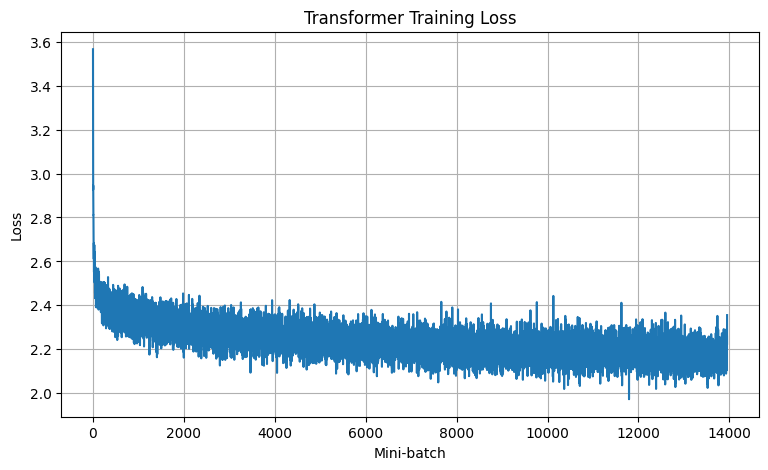


Transformer生成的50个名字：
01. braiso
02. salviers
03. radel
04. sparret
05. mana
06. lew
07. ahlon
08. strett
09. allefo
10. driscottt
11. stetter
12. monte
13. amoe
14. charter
15. salli
16. josil
17. bennor
18. ischram
19. grane
20. shiha
21. seatham
22. capp
23. campson
24. lavi
25. linna
26. nat
27. brickford
28. collan
29. wolh
30. tau
31. sheiny
32. wests
33. montara
34. bitts
35. sticker
36. stales
37. tenetta
38. acklor
39. stammen
40. rowle
41. hatson
42. brunden
43. graca
44. harbela
45. ur
46. kind
47. pato
48. tacus
49. bromenham
50. whiter


In [50]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 重新固定随机种子，使实验可以复现
random.seed(123)
np.random.seed(123)
torch.manual_seed(123)

# =========================
# 1. 位置编码
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_length=100):
        super().__init__()

        position = torch.arange(
            max_length,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_length, d_model)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )

    def forward(self, x):
        sequence_length = x.size(1)

        return x + self.pe[:, :sequence_length]


# =========================
# 2. 定义Transformer模型
# =========================
class TransformerNameModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_ID
        )

        self.position_encoding = PositionalEncoding(
            d_model=d_model,
            max_length=100
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, vocab_size)

    def create_causal_mask(self, sequence_length, device):
        # 上三角区域为负无穷，防止模型看到未来字符
        mask = torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                device=device
            ),
            diagonal=1
        )

        mask = mask.masked_fill(mask == 1, float("-inf"))

        return mask

    def forward(self, x):
        sequence_length = x.size(1)

        # 嵌入并进行缩放
        x_embedding = self.embedding(x) * math.sqrt(self.d_model)

        # 加入位置编码
        x_embedding = self.position_encoding(x_embedding)

        # 因果掩码
        causal_mask = self.create_causal_mask(
            sequence_length,
            x.device
        )

        # PAD掩码
        padding_mask = (x == PAD_ID)

        output = self.transformer(
            x_embedding,
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )

        logits = self.fc(output)

        return logits


transformer_model = TransformerNameModel(
    vocab_size=vocab_size,
    d_model=128,
    nhead=4,
    num_layers=3,
    dim_feedforward=256,
    dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=0.001
)

# =========================
# 3. 训练Transformer
# =========================
num_epochs = 30
losses_transformer = []

for epoch in range(num_epochs):
    transformer_model.train()

    epoch_loss = 0.0

    for input_ids, target_ids in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        optimizer.zero_grad()

        logits = transformer_model(input_ids)

        loss = criterion(
            logits.reshape(-1, vocab_size),
            target_ids.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transformer_model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        epoch_loss += loss.item()
        losses_transformer.append(loss.item())

    average_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}], "
            f"Loss: {average_loss:.4f}"
        )

# =========================
# 4. 绘制损失曲线
# =========================
plt.figure(figsize=(9, 5))
plt.plot(losses_transformer)
plt.xlabel("Mini-batch")
plt.ylabel("Loss")
plt.title("Transformer Training Loss")
plt.grid()
plt.show()

# =========================
# 5. Transformer生成名字
# =========================
def generate_transformer_name(
    model,
    max_length=15,
    temperature=0.8
):
    model.eval()

    generated_ids = [BOS_ID]

    with torch.no_grad():
        for _ in range(max_length):
            input_ids = torch.tensor(
                [generated_ids],
                dtype=torch.long,
                device=device
            )

            logits = model(input_ids)

            # 取最后一个位置预测下一个字符
            next_logits = logits[:, -1, :] / temperature

            # 禁止生成PAD和BOS
            next_logits[:, PAD_ID] = float("-inf")
            next_logits[:, BOS_ID] = float("-inf")

            probabilities = torch.softmax(
                next_logits,
                dim=-1
            )

            next_token = torch.multinomial(
                probabilities,
                num_samples=1
            ).item()

            if next_token == EOS_ID:
                break

            generated_ids.append(next_token)

    generated_chars = [
        itos[token_id]
        for token_id in generated_ids[1:]
    ]

    return "".join(generated_chars)


generated_transformer_names = []

while len(generated_transformer_names) < 50:
    name = generate_transformer_name(
        transformer_model,
        max_length=15,
        temperature=0.8
    )

    if len(name) >= 2:
        generated_transformer_names.append(name)

print("\nTransformer生成的50个名字：")

for i, name in enumerate(generated_transformer_names, 1):
    print(f"{i:02d}. {name}")

## 4. AI 辅助编程工具实战

利用 OpenCode、Claude Code 等 AI 辅助编程工具完成一个小项目的实践，建议贴近日常生活，发挥自己的创意，如编写一个 HTML 小游戏、制作一份个人简历等，主题不限。请把你完成项目的过程录制成一段视频，重点体现你和 Coding Agent 的交互，完成后将视频文件传到 Canvas 中进行提交。